In [151]:
import json
import pandas as pd

## Part I: Importing the data

In [152]:
with open('/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/src/data/scraper/data.json',"r") as file:
    tree=json.load(file)

In [153]:
nodes=pd.DataFrame(tree["nodes"])

In [154]:
#338530 mpg entries as scraped on June 3
len(nodes)

338530

In [155]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338530 entries, 0 to 338529
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        338530 non-null  int64  
 1   name      338524 non-null  object 
 2   thesis    307398 non-null  object 
 3   school    281804 non-null  object 
 4   country   322984 non-null  object 
 5   year      277239 non-null  float64
 6   subject   202490 non-null  object 
 7   advisors  338530 non-null  object 
 8   students  338530 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 23.2+ MB


## Part II: First sanity check

In [156]:
#check the entries with wrong 'year'
nodes.sort_values(by='year').head(10)

,id,name,thesis,school,country,year,subject,advisors,students
94320,95595,Gwénaelle Piriou,Modélisation statistique du mouvement dans des...,Université de Renne,France,1.0,62—Statistics,"[95576, 95575]",[]
79661,80496,Pierre Charrier,None,Université Bordeau,France,1.0,35—Partial differential equations,"[112979, 59156]","[84842, 56104, 80400]"
80151,81006,Maria Luiza Lapa de Souza,None,Université Paris Diderot - Pari,France,7.0,None,[47121],[]
77386,78148,Sylvestre F. L. (Sylvain) Gallot,None,Université Paris Diderot - Pari,France,7.0,53—Differential geometry,[36696],"[78165, 55827, 331187, 78167, 101114, 101114, ..."
337176,344761,Kesina Baral,Towards Effective Test Oracle Automation,George Mason University,UnitedStates,22.0,68—Computer science,[127076],[]
255788,261324,Jaimee Brown,Secure public-key encryption from factorisatio...,Queensland University of Technology,Australia,200.0,68—Computer science,"[261313, 18983]",[]
336776,344359,Elaina Aceves,Train tracks of pseudo-Anosov 3-braids and non...,The University of Iowa,UnitedStates,202.0,57—Manifolds and cell complexes,[97534],[]
281499,287496,Shams al Dīn Muhammed ibn Ibrāhim,None,,None,1300.0,None,[287495],[]
292971,299082,Hugo Grotius (de Groot),"De infinito, loco, et vacuo",Universiteit Leiden,Netherlands,1597.0,None,[125233],[]
292930,299041,Joannes van der Haghe,De motu eiusque speciebus,Universiteit Leiden,Netherlands,1599.0,None,[125023],[]


#The 'year' in the first 7 entries is obviously wrong. After web search, we found the first four are fetching mistakes (messed up the name of the school, which contains number), and the last three are mistakes originated from mgp pages. We fix them below:

In [157]:
nodes.loc[nodes['id'] == 95595, ['school', 'year']] = ['Université of Rennes 1', None]
nodes.loc[nodes['id'] == 80496, ['school', 'year']] = ['Université Bordeaux 1', None]
nodes.loc[nodes['id'] == 78148, ['school', 'year']] = ['Université Paris Diderot - Paris 7', None]
nodes.loc[nodes['id'] == 81006, ['school', 'year']] = ['Université Paris Diderot - Paris 7', None]
nodes.loc[nodes['id'] == 344761, 'year'] = 2022
nodes.loc[nodes['id'] == 261324, 'year'] = 2007
nodes.loc[nodes['id'] == 344359, 'year'] = 2022 #the explicit year in the last three entries come from google search
nodes[nodes['id'] == 344359]

,id,name,thesis,school,country,year,subject,advisors,students
336776,344359,Elaina Aceves,Train tracks of pseudo-Anosov 3-braids and non...,The University of Iowa,UnitedStates,2022.0,57—Manifolds and cell complexes,[97534],[]


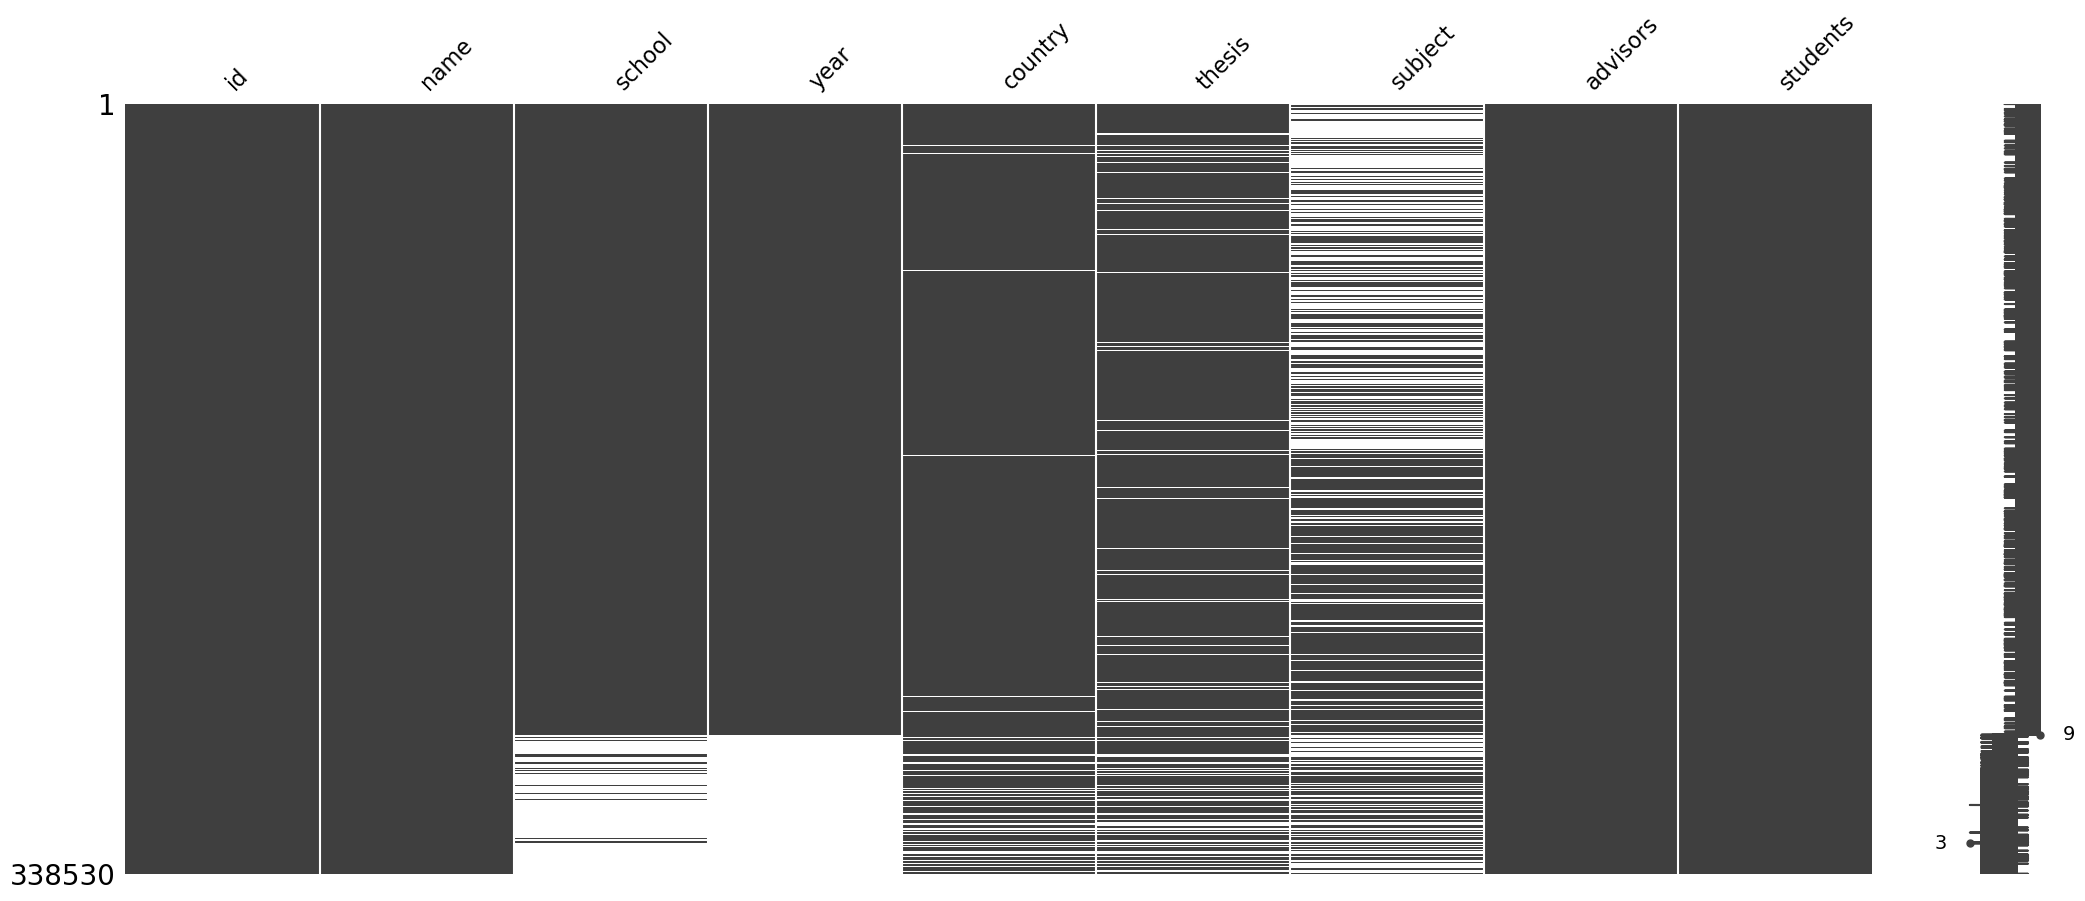

In [158]:
#missing data analysis
import matplotlib.pyplot as plt
import missingno as msno

msno.matrix(nodes.reindex(columns=['id','name','school', 'year', 'country','thesis','subject','advisors','students']).sort_values(by='year'))
plt.show()


## Observation of the missing data:
1. The year missing is correlated with school missing;
2. In the early years (near top on the black bar), the subjects tend to be missing; 
3. If the 'year' is missing, then 'country' and 'thesis' tend to be missing


In [159]:
nodes.sample(100)

,id,name,thesis,school,country,year,subject,advisors,students
51698,52054,Georg Kissel,Über den von den Trifektionslinien eines Dreie...,None,Germany,NaN,None,[47610],[]
116528,119368,Christine Lorraine Ray,Dynamics and Persistence of Spatially Structur...,"University of California, Davis",UnitedStates,1997.0,92—Biology and other natural sciences,[25017],[]
51426,51791,Richard Schwarz,Der Eisensteinsche Satz über die Koefficienten...,None,Germany,NaN,None,[18599],[]
29783,29942,Tran Trong Nghia,Über stationäre Punkte quadratischer Optimieru...,Humboldt-Universität zu Berlin,Germany,1983.0,None,[20780],[]
355,359,William Waldron Schieffelin Claytor,Topological Immersion of Peanian Continua in a...,University of Pennsylvania,UnitedStates,1933.0,None,[287],[]
...,...,...,...,...,...,...,...,...,...
247025,252349,J. Abdul Samath,Neural Networks and Simulink Approaches for So...,Gandhigram Rural Institute,India,2008.0,93—Systems theory; control,[135685],[]
265845,271568,Li Chen,A quasicontinuum approach towards mechanical s...,Université du Luxembourg,Luxembourg,2020.0,74—Mechanics of deformable solids,"[243565, 177070]",[]
210921,215740,H. E. (Ted) Frech,The Regulation of Health Insurance,"University of California, Los Angeles",UnitedStates,1974.0,"91—Game theory, economics, social and behavior...",[],[215742]
209181,213967,Tetyana Surovtseva,"Essays on Labor Markets, Migration and Trade",Universitat Pompeu Fabra,Spain,2015.0,"91—Game theory, economics, social and behavior...",[201725],[]


In [160]:
#We know there are two entries with fetching errors:
nodes[(nodes['id'] == 29316) | (nodes['id'] == 100043)]

,id,name,thesis,school,country,year,subject,advisors,students


In [161]:
#adding entry manually for id=29316
new_row = {
  'id': 29316,
  'name': "Detlef Dürr",
  'thesis': "Wahrscheinlichste Wege von Diffusionsprozessen",
  'school': "Universität Münster",
  'country': "Germany",
  'year': 1978.0,
  'subject': "60—Probability theory and stochastic processes",
  'advisors': [300879],
  'students': [49602, 191494, 273114, 28892, 28895, 171502, 77148, 191496, 269414, 269415, 191498, 191492, 270001, 191495, 97197, 119112, 191501, 191499]
}
nodes = pd.concat([nodes, pd.DataFrame([new_row])], ignore_index=True)

In [162]:
#adding entry manually for id=100043
new_row_1 = {
  'id': 100043,
  'name': "Dmitri Loguinov",
  'thesis': "Adaptive Scalable Internet Streaming",
  'school': "City University of New York",
  'country': "UnitedStates",
  'year': 2002.0,
  'subject': "68—Computer science",
  'advisors': [99811],
  'students': [231378, 231380, 120300, 123732, 150492, 231377, 150493, 231379, 136368, 136548, 120361]
}
nodes = pd.concat([nodes, pd.DataFrame([new_row_1])], ignore_index=True)

#may run the previous code again to check they are included

In [163]:
nodes[(nodes['id'] == 29316) | (nodes['id'] == 100043)]

,id,name,thesis,school,country,year,subject,advisors,students
338530,29316,Detlef Dürr,Wahrscheinlichste Wege von Diffusionsprozessen,Universität Münster,Germany,1978.0,60—Probability theory and stochastic processes,[300879],"[49602, 191494, 273114, 28892, 28895, 171502, ..."
338531,100043,Dmitri Loguinov,Adaptive Scalable Internet Streaming,City University of New York,UnitedStates,2002.0,68—Computer science,[99811],"[231378, 231380, 120300, 123732, 150492, 23137..."


In [164]:
# turn 'year' to an integer (allow NaN)
nodes['year'] = pd.to_numeric(nodes['year'], errors='coerce').astype('Int64')

In [165]:
import pandas as pd
import numpy as np
from collections import Counter
from ast import literal_eval

# Make a safe working copy
df = nodes.copy()

# If id is currently the index, bring it back as a column
if "id" not in df.columns:
    if df.index.name == "id":
        df = df.reset_index()
    else:
        raise ValueError("Cannot find an 'id' column. If id is the index, make sure nodes.index.name == 'id'.")

records = df.to_dict("records")


def is_empty(x):
    if x is None:
        return True
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    try:
        if pd.isna(x):
            return True
    except (TypeError, ValueError):
        pass
    if isinstance(x, str):
        return x.strip() == "" or x.strip().lower() in {"nan", "none"}
    return False


def parse_positive_int(x):
    if is_empty(x):
        raise ValueError("missing")

    if isinstance(x, bool):
        raise ValueError("boolean is not a valid ID")

    if isinstance(x, (int, np.integer)):
        n = int(x)
    elif isinstance(x, (float, np.floating)):
        if not float(x).is_integer():
            raise ValueError("non-integer float")
        n = int(x)
    elif isinstance(x, str):
        s = x.strip()
        try:
            f = float(s)
        except ValueError:
            raise ValueError("not numeric")
        if not f.is_integer():
            raise ValueError("non-integer string")
        n = int(f)
    else:
        raise ValueError("unrecognized type")

    if n <= 0:
        raise ValueError("ID must be positive")

    return n


def to_int_set_and_bad(value):
    if is_empty(value):
        return set(), []

    # If advisor/student lists were saved as strings, try to parse them
    if isinstance(value, str):
        try:
            value = literal_eval(value)
        except Exception:
            value = [value]

    if not isinstance(value, (list, tuple, set)):
        value = [value]

    good = set()
    bad = []

    for item in value:
        try:
            good.add(parse_positive_int(item))
        except ValueError:
            bad.append(item)

    return good, bad


# ---------------------------------------
# 1. Validate and index IDs
# ---------------------------------------

valid_records = []
invalid_id_records = []

for row_number, record in enumerate(records):
    try:
        record_id = parse_positive_int(record.get("id"))
        valid_records.append((record_id, record))
    except ValueError:
        invalid_id_records.append((row_number, record.get("id"), record))

id_counts = Counter(record_id for record_id, _ in valid_records)

duplicate_ids = sorted([
    record_id
    for record_id, count in id_counts.items()
    if count > 1
])

by_id = {
    record_id: record
    for record_id, record in valid_records
}


# ---------------------------------------
# 2. Check important fields
# ---------------------------------------

fields_to_check = [
    "name",
    "thesis",
    "school",
    "country",
    "year",
    "subject",
    "advisors",
    "students",
]

missing_names = [
    record_id
    for record_id, record in valid_records
    if is_empty(record.get("name"))
]

completely_empty_records = [
    record_id
    for record_id, record in valid_records
    if all(is_empty(record.get(field)) for field in fields_to_check)
]


# ---------------------------------------
# 3. Check advisor/student references
# ---------------------------------------

dangling_advisor_links = []
dangling_student_links = []

advisor_student_mismatches = []
student_advisor_mismatches = []

bad_advisor_entries = []
bad_student_entries = []

self_links = []

for person_id, record in valid_records:
    advisors, bad_advisors = to_int_set_and_bad(record.get("advisors"))
    students, bad_students = to_int_set_and_bad(record.get("students"))

    for bad in bad_advisors:
        bad_advisor_entries.append((person_id, bad))

    for bad in bad_students:
        bad_student_entries.append((person_id, bad))

    if person_id in advisors:
        self_links.append((person_id, "listed as own advisor"))

    if person_id in students:
        self_links.append((person_id, "listed as own student"))

    for advisor_id in advisors:
        if advisor_id not in by_id:
            dangling_advisor_links.append((person_id, advisor_id))
        else:
            advisor_students, _ = to_int_set_and_bad(by_id[advisor_id].get("students"))
            if person_id not in advisor_students:
                advisor_student_mismatches.append((person_id, advisor_id))

    for student_id in students:
        if student_id not in by_id:
            dangling_student_links.append((person_id, student_id))
        else:
            student_advisors, _ = to_int_set_and_bad(by_id[student_id].get("advisors"))
            if person_id not in student_advisors:
                student_advisor_mismatches.append((person_id, student_id))


# ---------------------------------------
# 4. Print report
# ---------------------------------------

print("Total records:", len(records))
print("Unique valid IDs:", len(by_id))
print("Invalid ID records:", len(invalid_id_records))
print("Duplicate IDs:", len(duplicate_ids))
print("Missing names:", len(missing_names))
print("Completely empty records:", len(completely_empty_records))

print()
print("Bad advisor entries:", len(bad_advisor_entries))
print("Bad student entries:", len(bad_student_entries))
print("Self links:", len(self_links))
print("Dangling advisor links:", len(dangling_advisor_links))
print("Dangling student links:", len(dangling_student_links))
print("Advisor/student mismatches:", len(advisor_student_mismatches))
print("Student/advisor mismatches:", len(student_advisor_mismatches))

print()
print("First invalid ID records:", [(r, bad_id) for r, bad_id, _ in invalid_id_records[:10]])
print("First duplicate IDs:", duplicate_ids[:10])
print("First missing-name IDs:", missing_names[:10])
print("First completely empty records:", completely_empty_records[:10])

print()
print("First bad advisor entries:", bad_advisor_entries[:10])
print("First bad student entries:", bad_student_entries[:10])
print("First self links:", self_links[:10])
print("First dangling advisor links:", dangling_advisor_links[:10])
print("First dangling student links:", dangling_student_links[:10])
print("First advisor/student mismatches:", advisor_student_mismatches[:10])
print("First student/advisor mismatches:", student_advisor_mismatches[:10])

Total records: 338532
Unique valid IDs: 338532
Invalid ID records: 0
Duplicate IDs: 0
Missing names: 6
Completely empty records: 5

Bad advisor entries: 0
Bad student entries: 0
Self links: 8
Dangling advisor links: 0
Dangling student links: 0
Advisor/student mismatches: 0
Student/advisor mismatches: 1456

First invalid ID records: []
First duplicate IDs: []
First missing-name IDs: [193664, 252305, 280915, 281175, 282607, 282657]
First completely empty records: [193664, 252305, 280915, 281175, 282657]

First bad advisor entries: []
First bad student entries: []
First self links: [(44767, 'listed as own advisor'), (44767, 'listed as own student'), (134752, 'listed as own advisor'), (134752, 'listed as own student'), (160529, 'listed as own advisor'), (160529, 'listed as own student'), (291585, 'listed as own advisor'), (291585, 'listed as own student')]
First dangling advisor links: []
First dangling student links: []
First advisor/student mismatches: []
First student/advisor mismatches

## We found a few alerts:

1. There are missing names (including 5 empty rows)
2. There are self-loops, i.e., a mathematician lists themselves as a student.
3. There are 1456 student/advisor mismatches, i.e., the advisor lists the student but the student does not list the advisor.

In [166]:
#mistake in case 1
rows_with_missing_name = nodes[nodes["name"].isna()]
rows_with_missing_name

,id,name,thesis,school,country,year,subject,advisors,students
189172,193664,None,None,None,None,<NA>,None,[],[]
246985,252305,None,None,None,None,<NA>,None,[],[]
275026,280915,None,None,None,None,<NA>,None,[],[]
275272,281175,None,None,None,None,<NA>,None,[],[]
276679,282607,None,A COMPUTATIONAL FRAMEWORK FOR ASSESSING CONNEC...,,None,2022,None,[190786],[]
276726,282657,None,None,None,None,<NA>,None,[],[]


We find 5 empty rows, and one row with missing name. This is fine, and web search indicates the mistakes originated from mgp webistes.

To avoid additional trouble caused by deleting a row (i.e., gaps in 'id'), we will keep them.

In [167]:
#mistake in case 2
nodes[nodes['id']==44767]

,id,name,thesis,school,country,year,subject,advisors,students
44467,44767,Edit Gombay,None,University of Calgary,Canada,2003,62—Statistics,[44767],"[44767, 72346, 44763]"


We notice that both 'advisors' and 'students' contain 44767. We will deal with that later.

In [168]:
#mistake in case 3
nodes[(nodes['id'] == 453) | (nodes['id'] == 164111)]

,id,name,thesis,school,country,year,subject,advisors,students
450,453,Jimmie Don Lawson,Vietoris Mappings and Embeddings of Topologica...,University of Tennessee - Knoxville,UnitedStates,1967,None,[451],"[96276, 96277, 3265, 3228, 3303, 14760, 164111..."
160010,164111,Sejong Kim,Symmetric Spaces,Louisiana State University,UnitedStates,2011,20—Group theory and generalizations,[],[]


We find 'id'=453 lists 'id'=164111 as student, but 'id'=164111 has no listed advisor. 

Web search shows that the mgp website is correct, so the mistake comes from fetching. We will fix this by adding the advisor back below.

In [169]:
nodes_fixed = nodes.copy()

# Make sure id is the index
if "id" in nodes_fixed.columns:
    nodes_fixed = nodes_fixed.set_index("id")

In [170]:
from ast import literal_eval
import pandas as pd
import numpy as np

def is_empty(x):
    if x is None:
        return True
    try:
        if pd.isna(x):
            return True
    except (TypeError, ValueError):
        pass
    if isinstance(x, str):
        return x.strip() == "" or x.strip().lower() in {"nan", "none"}
    if isinstance(x, (list, tuple, set)):
        return len(x) == 0
    return False


def normalize_id_list(x):
    """
    Convert advisors/students field into a clean list of ints.
    """
    if is_empty(x):
        return []

    # In case the list was saved as a string like "[1, 2, 3]"
    if isinstance(x, str):
        try:
            x = literal_eval(x)
        except Exception:
            x = [x]

    if not isinstance(x, (list, tuple, set)):
        x = [x]

    result = []
    for item in x:
        if not is_empty(item):
            result.append(int(item))

    return result

In [171]:
num_added = 0

for advisor_id, student_id in student_advisor_mismatches:
    advisor_id = int(advisor_id)
    student_id = int(student_id)

    if advisor_id not in nodes_fixed.index:
        print("Missing advisor id:", advisor_id)
        continue

    if student_id not in nodes_fixed.index:
        print("Missing student id:", student_id)
        continue

    advisors = normalize_id_list(nodes_fixed.at[student_id, "advisors"])

    if advisor_id not in advisors:
        advisors.append(advisor_id)
        nodes_fixed.at[student_id, "advisors"] = advisors
        num_added += 1

print("Number of advisor links added:", num_added)

Number of advisor links added: 1456


In [172]:
#quick sanity check again
453 in nodes_fixed.loc[164111, "advisors"]

True

So the `nodes_fixed` fixes the mistake in case 3. You can also wrong the previous code with `nodes` replaced by `nodes_fixed` to check.

## Part III: Change the index using id

In [173]:
nodes_fixed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338532 entries, 1 to 100043
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   name      338526 non-null  object
 1   thesis    307400 non-null  object
 2   school    281806 non-null  object
 3   country   322986 non-null  object
 4   year      277237 non-null  Int64 
 5   subject   202492 non-null  object
 6   advisors  338532 non-null  object
 7   students  338532 non-null  object
dtypes: Int64(1), object(7)
memory usage: 31.6+ MB


In [174]:
# sort the entries monotonically by index
nodes_fixed = nodes_fixed.sort_index()

In [175]:
nodes_fixed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338532 entries, 1 to 346123
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   name      338526 non-null  object
 1   thesis    307400 non-null  object
 2   school    281806 non-null  object
 3   country   322986 non-null  object
 4   year      277237 non-null  Int64 
 5   subject   202492 non-null  object
 6   advisors  338532 non-null  object
 7   students  338532 non-null  object
dtypes: Int64(1), object(7)
memory usage: 23.6+ MB


In [176]:
nodes_fixed.index.max()

np.int64(346123)

In [177]:
# Convert the modified DataFrame back to a list of dictionaries
tree["nodes"] = nodes_fixed.to_dict('records')

# Write back to the JSON file
with open('/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/raw/data-new.json', 'w') as file:
    json.dump(tree, file, indent=2)